## Imports

In [1]:
import json
from collections import Counter

## Load Dataset

In [2]:
with open("../data/raw/train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

with open("../data/raw/test.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

print("Train samples:", len(train_data))
print("Test samples:", len(test_data))

Train samples: 28516
Test samples: 3650


## Inspecting a single sample

In [3]:
train_data[0]

{'lang': 'en',
 'ner_tags': ['O',
  'O',
  'O',
  'O',
  'B-PER',
  'I-PER',
  'O',
  'O',
  'O',
  'O',
  'B-PER',
  'I-PER',
  'O',
  'O',
  'O',
  'O',
  'O',
  'B-PER',
  'I-PER',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O'],
 'sequence': 'Since then , only Terry Bradshaw in 147 games , Joe Montana in 139 games , and Tom Brady in 131 games have reached 100 wins more quickly .',
 'tokens': ['Since',
  'then',
  ',',
  'only',
  'Terry',
  'Bradshaw',
  'in',
  '147',
  'games',
  ',',
  'Joe',
  'Montana',
  'in',
  '139',
  'games',
  ',',
  'and',
  'Tom',
  'Brady',
  'in',
  '131',
  'games',
  'have',
  'reached',
  '100',
  'wins',
  'more',
  'quickly',
  '.']}

## Checking token tag alignment

In [4]:
example = train_data[0]

for token, tag in zip(example["tokens"], example["ner_tags"]):
    print(f"{token} --> {tag}")

Since --> O
then --> O
, --> O
only --> O
Terry --> B-PER
Bradshaw --> I-PER
in --> O
147 --> O
games --> O
, --> O
Joe --> B-PER
Montana --> I-PER
in --> O
139 --> O
games --> O
, --> O
and --> O
Tom --> B-PER
Brady --> I-PER
in --> O
131 --> O
games --> O
have --> O
reached --> O
100 --> O
wins --> O
more --> O
quickly --> O
. --> O


## Column wise tag distribution

In [5]:
tag_counter = Counter()

for example in train_data:
    tag_counter.update(example["ner_tags"])

tag_counter

Counter({'O': 639055, 'B-PER': 40264, 'I-PER': 29466})

## Checking Missing Emails

In [8]:
print("B-EMAIL:", tag_counter.get("B-EMAIL", 0))
print("I-EMAIL:", tag_counter.get("I-EMAIL", 0))

B-EMAIL: 0
I-EMAIL: 0


## Visualization

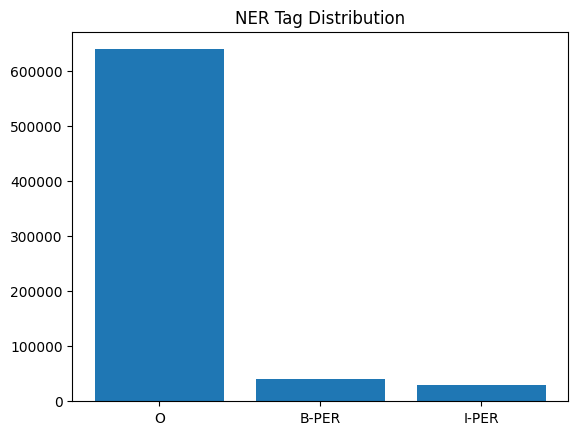

In [9]:
import matplotlib.pyplot as plt

labels = list(tag_counter.keys())
values = list(tag_counter.values())

plt.bar(labels, values)
plt.title("NER Tag Distribution")
plt.show()